# NIST RAG + Agent 시스템

## 목표
- 1단계에서 만든 RAG를 Tool로 래핑
- LangChain Agent로 대화형 컨설턴트 구축
- LangGraph로 Agent 플로우 구성
- LangSmith로 Agent 실행 추적

## 구성 요소
1. **RAG Tool**: NIST 문서 검색 도구
2. **Agent**: ReAct 패턴 기반 대화형 컨설턴트
3. **Memory**: 대화 히스토리 관리
4. **LangGraph**: Agent 실행 플로우 관리


## 1. 환경 설정 및 패키지 임포트


In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from typing import List, Dict, Annotated

# LangChain Core
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage
from langchain_core.chat_history import BaseChatMessageHistory, InMemoryChatMessageHistory
from langchain_core.runnables import RunnableWithMessageHistory

# LangChain Tools & Agents
from langchain.tools import tool
from langchain.agents import create_agent

# Pinecone
from pinecone import Pinecone
from langchain_pinecone import PineconeVectorStore

# LangGraph
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from typing import TypedDict

print("✅ 패키지 임포트 완료")


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ 패키지 임포트 완료


In [2]:
# 환경 변수 로드
load_dotenv()

# 환경 변수 확인
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
PINECONE_API_KEY = os.getenv("PINECONE_API_KEY")
LANGSMITH_API_KEY = os.getenv("LANGSMITH_API_KEY")
LANGSMITH_PROJECT = os.getenv("LANGSMITH_PROJECT")


# LangSmith 설정
os.environ["LANGSMITH_TRACING"] = "true"

print(f"OPENAI_API_KEY 설정: {bool(OPENAI_API_KEY)}")
print(f"PINECONE_API_KEY 설정: {bool(PINECONE_API_KEY)}")
print(f"LANGSMITH_API_KEY 설정: {bool(LANGSMITH_API_KEY)}")
print(f"LangSmith 프로젝트: {os.getenv('LANGSMITH_PROJECT')}")


OPENAI_API_KEY 설정: True
PINECONE_API_KEY 설정: True
LANGSMITH_API_KEY 설정: True
LangSmith 프로젝트: pr-candid-waterspout-31


## 2. Pinecone VectorStore 연결


In [3]:
# Pinecone 클라이언트 초기화
pc = Pinecone(api_key=PINECONE_API_KEY)

# 인덱스 이름 (01 노트북에서 생성한 것)
index_name = "nist-rag-index"

# 임베딩 모델 설정
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    openai_api_key=OPENAI_API_KEY
)

# 기존 VectorStore 연결
vectorstore = PineconeVectorStore(
    index_name=index_name,
    embedding=embeddings
)

print(f"✅ Pinecone VectorStore 연결 완료")
print(f"📌 인덱스: {index_name}")


✅ Pinecone VectorStore 연결 완료
📌 인덱스: nist-rag-index


In [4]:
# 검색 테스트
test_results = vectorstore.similarity_search("AI 리스크 관리", k=2)
print(f"🔍 검색 테스트:")
for i, doc in enumerate(test_results, 1):
    print(f"  [{i}] {doc.metadata['doc_title']} - {doc.page_content[:80]}...")


🔍 검색 테스트:
  [1] NIST AI Risk Management Framework - NIST AI 100-1 AI RMF 1.0
Practices related to managing AI risks are described in...
  [2] NIST AI Risk Management Framework - age the risks of deployed AI systems and to allocate risk management resources b...


## 3. RAG 체인 재구축


In [5]:
# Retriever 생성
retriever = vectorstore.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 4}
)

# LLM 설정
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    openai_api_key=OPENAI_API_KEY
)

# RAG 프롬프트
rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 NIST 문서를 기반으로 답변하는 보안 및 AI 전문가입니다.

제공된 컨텍스트를 바탕으로 정확하게 답변하세요.
반드시 어떤 NIST 문서를 참고했는지 명시하세요.

컨텍스트:
{context}
"""),
    ("human", "{question}")
])

# 문서 포맷팅 함수
def format_docs(docs):
    formatted = []
    for i, doc in enumerate(docs, 1):
        formatted.append(
            f"[문서 {i}] {doc.metadata['doc_title']} (페이지 {doc.metadata['page']})\n"
            f"{doc.page_content}\n"
        )
    return "\n\n".join(formatted)

# RAG 체인 조립
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

print("✅ RAG 체인 재구축 완료")


✅ RAG 체인 재구축 완료


## 4. RAG를 LangChain Tool로 래핑


In [6]:
@tool
def nist_rag_tool(question: str) -> str:
    """
    NIST 문서를 검색하여 질문에 답변합니다.
    
    이 도구는 다음 NIST 문서들을 검색합니다:
    - NIST AI Risk Management Framework (AI RMF)
    - NIST Cybersecurity Framework 2.0 (CSF 2.0)
    - NIST Zero Trust Architecture
    
    AI 보안, 리스크 관리, 사이버보안, Zero Trust에 관한 질문에 답변할 수 있습니다.
    
    Args:
        question: NIST 문서에 대한 질문
        
    Returns:
        NIST 문서에 근거한 답변 (출처 포함)
    """
    try:
        answer = rag_chain.invoke(question)
        return answer
    except Exception as e:
        return f"NIST 문서 검색 중 오류가 발생했습니다: {str(e)}"

# Tool 리스트
tools = [nist_rag_tool]

print("✅ NIST RAG Tool 생성 완료")
print(f"   - Tool 이름: {nist_rag_tool.name}")
print(f"   - Tool 설명: {nist_rag_tool.description[:80]}...")


✅ NIST RAG Tool 생성 완료
   - Tool 이름: nist_rag_tool
   - Tool 설명: NIST 문서를 검색하여 질문에 답변합니다.

이 도구는 다음 NIST 문서들을 검색합니다:
- NIST AI Risk Management Fr...


In [7]:
# Tool 단독 테스트
test_question = "Zero Trust의 핵심 원칙은?"
print(f"🧪 Tool 테스트: {test_question}\n")
test_result = nist_rag_tool.invoke({"question": test_question})
print(f"답변:\n{test_result}")


🧪 Tool 테스트: Zero Trust의 핵심 원칙은?



/opt/homebrew/lib/python3.10/site-packages/pydantic/v1/main.py:1054: UserWarning: LangSmith now uses UUID v7 for run and trace identifiers. This warning appears when passing custom IDs. Please use: from langsmith import uuid7
            id = uuid7()
Future versions will require UUID v7.
  input_data = validator(cls_, input_data)


답변:
Zero Trust의 핵심 원칙은 다음과 같습니다:

1. **모든 데이터 소스와 컴퓨팅 서비스는 자원으로 간주**: 네트워크는 다양한 클래스의 장치로 구성될 수 있으며, 개인 소유 장치도 기업 자원에 접근할 수 있는 경우 자원으로 분류될 수 있습니다. (출처: NIST SP 800-207, 페이지 14.0)

2. **신뢰는 암묵적으로 부여되지 않음**: Zero Trust는 자원 보호에 중점을 두며, 신뢰는 지속적으로 평가되어야 합니다. 이는 최소 권한 원칙을 적용하여 접근을 제한하는 것을 포함합니다. (출처: NIST SP 800-207, 페이지 12.0)

3. **최소 권한 부여**: 자원에 대한 접근은 필요에 따라 제한되며, 사용자에게는 최소한의 권한만 부여됩니다. (출처: NIST SP 800-207, 페이지 12.0)

4. **네트워크를 타협된 것으로 간주**: Zero Trust 아키텍처는 네트워크가 이미 타협되었다고 가정하고, 이에 따라 접근 결정을 내립니다. (출처: NIST SP 800-207, 페이지 12.0)

이러한 원칙들은 Zero Trust 아키텍처(ZTA)의 설계 및 배포에 있어 중요한 요소로 작용합니다.


## 5. Agent 구성 (create_agent)


In [8]:
# Agent 모델 설정
agent_model = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
    openai_api_key=OPENAI_API_KEY
)

# System Prompt
system_prompt = """당신은 NIST 기반 AI 보안 및 사이버보안 컨설턴트입니다.

역할:
- 조직의 AI 리스크 관리를 돕는다
- 사이버보안 프레임워크 적용을 지원한다
- Zero Trust 아키텍처 전환을 컨설팅한다

작업 방식:
1. 사용자의 질문을 정확히 이해한다
2. 필요하면 nist_rag_tool을 사용하여 NIST 문서를 검색한다
3. 검색 결과를 바탕으로 명확하고 실용적인 답변을 제공한다
4. 항상 어떤 NIST 문서/섹션을 참고했는지 명시한다
5. 대화 맥락을 기억하고 이전 대화를 참고하여 답변한다

원칙:
- 가능한 모든 질문에 NIST RAG Tool을 우선 사용하라
- 근거가 부족하면 추측하지 말고 솔직하게 말하라
- 전문적이고 친절한 톤을 유지하라
"""

# Agent 생성
agent = create_agent(
    model=agent_model,
    tools=tools,
    system_prompt=system_prompt
)

print("✅ Agent 생성 완료")
print("   - 모델: gpt-4o-mini")
print("   - Tools: nist_rag_tool")
print("   - 패턴: ReAct (Reasoning + Acting)")


✅ Agent 생성 완료
   - 모델: gpt-4o-mini
   - Tools: nist_rag_tool
   - 패턴: ReAct (Reasoning + Acting)


## 6. Memory 추가 (대화 히스토리 관리)


In [9]:
# 세션별 메모리 저장소
_chat_store: Dict[str, InMemoryChatMessageHistory] = {}

def get_session_history(session_id: str) -> BaseChatMessageHistory:
    """세션 ID별로 대화 히스토리를 관리"""
    if session_id not in _chat_store:
        _chat_store[session_id] = InMemoryChatMessageHistory()
    return _chat_store[session_id]

# Agent에 Memory 추가
agent_with_memory = RunnableWithMessageHistory(
    agent,
    get_session_history,
    input_messages_key="messages",
    history_messages_key="history"
)

print("✅ Memory 기능 추가 완료")
print("   - 세션별 대화 히스토리 관리")
print("   - InMemoryChatMessageHistory 사용")


✅ Memory 기능 추가 완료
   - 세션별 대화 히스토리 관리
   - InMemoryChatMessageHistory 사용


## 7. LangGraph로 Agent 플로우 구성


In [10]:
# State 정의
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# Agent 노드 정의
def agent_node(state: AgentState) -> AgentState:
    """Agent를 실행하는 노드"""
    response = agent.invoke(state)
    return response

# LangGraph 구성
graph_builder = StateGraph(AgentState)
graph_builder.add_node("agent", agent_node)
graph_builder.set_entry_point("agent")
graph_builder.add_edge("agent", END)

# 그래프 컴파일
agent_graph = graph_builder.compile()

print("✅ LangGraph 구성 완료")
print("   - State: AgentState (messages)")
print("   - Nodes: agent")
print("   - Flow: START → agent → END")


✅ LangGraph 구성 완료
   - State: AgentState (messages)
   - Nodes: agent
   - Flow: START → agent → END


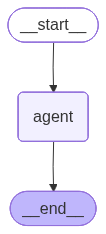

In [11]:
# LangGraph 시각화 (선택)
try:
    from IPython.display import Image, display
    display(Image(agent_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 스킵: {e}")


## 8. 헬퍼 함수 정의


In [12]:
def chat_with_agent(session_id: str, user_message: str, use_graph: bool = False) -> str:
    """
    Agent와 대화하는 헬퍼 함수
    
    Args:
        session_id: 세션 ID (대화 히스토리 관리용)
        user_message: 사용자 메시지
        use_graph: LangGraph 사용 여부
        
    Returns:
        Agent의 답변
    """
    messages = [{"role": "user", "content": user_message}]
    
    if use_graph:
        # LangGraph를 통한 실행
        config = {
            "tags": ["nist", "agent", "langgraph"],
            "run_name": "nist_agent_graph"
        }
        result = agent_graph.invoke(
            {"messages": messages},
            config=config
        )
    else:
        # 일반 Agent 실행 (Memory 포함)
        config = {
            "configurable": {"session_id": session_id},
            "tags": ["nist", "agent"],
            "run_name": "nist_agent_with_memory"
        }
        result = agent_with_memory.invoke(
            {"messages": messages},
            config=config
        )
    
    return result["messages"][-1].content

print("✅ 헬퍼 함수 정의 완료")
print("   - chat_with_agent(): Agent와 대화")
print("   - use_graph=True: LangGraph 사용")
print("   - use_graph=False: 일반 Agent + Memory 사용")


✅ 헬퍼 함수 정의 완료
   - chat_with_agent(): Agent와 대화
   - use_graph=True: LangGraph 사용
   - use_graph=False: 일반 Agent + Memory 사용


## 9. 시나리오 1: AI Risk Management 컨설팅


In [13]:
print("="*60)
print("🎯 시나리오 1: AI Risk Management 컨설팅")
print("="*60)
print("\n고객사: AI 기반 추천 시스템을 개발 중인 이커머스 회사")
print("목표: NIST AI RMF를 활용한 리스크 관리 프로세스 구축\\n")


🎯 시나리오 1: AI Risk Management 컨설팅

고객사: AI 기반 추천 시스템을 개발 중인 이커머스 회사
목표: NIST AI RMF를 활용한 리스크 관리 프로세스 구축\n


In [14]:
# 턴 1
session1 = "ai-risk-consulting"
q1 = "안녕하세요. 저희는 AI 기반 추천 시스템을 개발하고 있는데, NIST AI RMF를 어떻게 적용해야 할지 궁금합니다."

print(f"👤 고객: {q1}\\n")
a1 = chat_with_agent(session1, q1)
print(f"🤖 컨설턴트: {a1}\\n")


👤 고객: 안녕하세요. 저희는 AI 기반 추천 시스템을 개발하고 있는데, NIST AI RMF를 어떻게 적용해야 할지 궁금합니다.\n
🤖 컨설턴트: 안녕하세요! AI 기반 추천 시스템에 NIST AI 리스크 관리 프레임워크(AI RMF)를 적용하는 방법에 대해 안내해 드리겠습니다. 다음은 NIST AI RMF에 기반한 단계별 가이드입니다:

1. **GOVERN (거버넌스)**: AI 리스크 관리를 위한 거버넌스 구조 및 프로세스를 수립합니다.
   - 추천 시스템 개발 및 배포에 관련된 이해관계자의 역할과 책임을 정의합니다.
   - 공정성과 편향 관리와 같은 윤리적 AI 사용을 위한 정책을 마련합니다.

2. **MAP (매핑)**: AI 시스템의 맥락을 식별하고 매핑합니다. 여기에는 의도된 사용 및 잠재적 리스크가 포함됩니다.
   - 추천 시스템의 목적과 대상 청중을 명확히 정의합니다.
   - 추천 알고리즘 훈련에 사용되는 데이터 소스가 대표적이고 해로운 편향이 없는지 평가합니다.

3. **MEASURE (측정)**: AI 시스템과 관련된 성능 및 리스크를 평가합니다.
   - 추천 시스템의 효과성을 평가하기 위한 메트릭을 구현합니다. 예: 정확성, 사용자 만족도, 공정성.
   - 정기적인 감사를 통해 시스템이 설정된 윤리적 가이드라인 및 성능 기준을 준수하는지 측정합니다.

4. **MANAGE (관리)**: 식별된 리스크를 완화하고 AI 시스템을 개선하기 위한 전략을 개발합니다.
   - 편향, 프라이버시 문제 및 보안 취약점을 다루기 위한 리스크 관리 계획을 수립합니다.
   - 시스템의 성능 및 사용자 상호작용을 지속적으로 모니터링할 수 있는 피드백 메커니즘을 구축하여 반복적인 개선을 가능하게 합니다.

5. **인간-AI 상호작용**: 사용자와 추천 시스템 간의 상호작용을 이해하고 최적화합니다.
   - 시스템과 상호작용할 때 사용자 역할과 책임을 명확히 정의하여 책임성을 보장합니다.
   - 추천이 생성되는 방식에 대한 투명성을 제공하여

In [ ]:
# 턴 2
q2 = "AI RMF의 4가지 핵심 기능이 뭔가요? 각각 간단히 설명해주세요."

print(f"👤 고객: {q2}\\n")
a2 = chat_with_agent(session1, q2)
print(f"🤖 컨설턴트: {a2}\\n")


In [ ]:
# 턴 3
q3 = "그럼 'Govern' 기능을 우리 조직에 먼저 적용하려면 어떤 단계로 시작해야 하나요?"

print(f"👤 고객: {q3}\\n")
a3 = chat_with_agent(session1, q3)
print(f"🤖 컨설턴트: {a3}\\n")


In [ ]:
# 턴 4
q4 = "AI 시스템의 편향성(bias)을 평가하고 완화하는 것은 어느 기능에 해당하나요?"

print(f"👤 고객: {q4}\\n")
a4 = chat_with_agent(session1, q4)
print(f"🤖 컨설턴트: {a4}\\n")


In [ ]:
# 턴 5
q5 = "마지막으로, AI RMF를 적용할 때 가장 흔히 하는 실수나 주의할 점이 있을까요?"

print(f"👤 고객: {q5}\\n")
a5 = chat_with_agent(session1, q5)
print(f"🤖 컨설턴트: {a5}\\n")

print("="*60)
print("✅ 시나리오 1 완료 (총 5턴)")
print("="*60)


## 10. 시나리오 2: Zero Trust 전환 컨설팅 (LangGraph 사용)


In [15]:
print("="*60)
print("🎯 시나리오 2: Zero Trust 아키텍처 전환 컨설팅")
print("="*60)
print("\n고객사: 기존 경계 기반 보안에서 Zero Trust로 전환하려는 금융 회사")
print("목표: NIST Zero Trust 가이드를 활용한 전환 로드맵 수립")
print("특이사항: LangGraph를 통한 실행\\n")


🎯 시나리오 2: Zero Trust 아키텍처 전환 컨설팅

고객사: 기존 경계 기반 보안에서 Zero Trust로 전환하려는 금융 회사
목표: NIST Zero Trust 가이드를 활용한 전환 로드맵 수립
특이사항: LangGraph를 통한 실행\n


In [16]:
# 턴 1
session2 = "zero-trust-consulting"
q1 = "Zero Trust Architecture의 핵심 원칙이 무엇인가요? NIST 문서 기준으로 설명해주세요."

print(f"👤 고객: {q1}\\n")
a1 = chat_with_agent(session2, q1, use_graph=True)
print(f"🤖 컨설턴트: {a1}\\n")


👤 고객: Zero Trust Architecture의 핵심 원칙이 무엇인가요? NIST 문서 기준으로 설명해주세요.\n
🤖 컨설턴트: Zero Trust Architecture (ZTA)의 핵심 원칙은 다음과 같습니다:

1. **모든 데이터 소스와 컴퓨팅 서비스는 리소스로 간주**: 네트워크는 다양한 클래스의 장치로 구성될 수 있으며, 모든 장치는 리소스로 취급됩니다. 이는 개인 소유 장치도 포함될 수 있습니다.

2. **신뢰는 암묵적으로 부여되지 않음**: Zero Trust는 신뢰가 자동으로 주어지지 않고, 지속적으로 평가되어야 한다는 원칙에 기반합니다. 즉, 접근 권한은 최소한의 권한만 부여되며, 필요에 따라 조정됩니다.

3. **최소 권한 원칙**: 리소스에 대한 접근은 필요한 경우에만 허용되며, 사용자는 읽기, 쓰기, 삭제와 같은 최소한의 권한만 부여받습니다.

4. **네트워크가 손상된 것으로 간주**: Zero Trust는 네트워크가 이미 손상되었다고 가정하고, 이에 따라 접근 결정을 내립니다. 이는 내부 공격을 탐지하고 차단하는 데 유용합니다.

이러한 원칙들은 NIST SP 800-207 "Zero Trust Architecture" 문서에서 설명되고 있습니다. (페이지 12.0 및 14.0 참조)\n


In [ ]:
# 턴 2
q2 = "마이크로 세그멘테이션은 Zero Trust에서 어떤 역할을 하나요?"

print(f"👤 고객: {q2}\\n")
a2 = chat_with_agent(session2, q2, use_graph=True)
print(f"🤖 컨설턴트: {a2}\\n")


In [ ]:
# 턴 3
q3 = "기존 레거시 시스템이 많은 금융 회사가 Zero Trust로 전환할 때 가장 먼저 해야 할 일은 무엇인가요?"

print(f"👤 고객: {q3}\\n")
a3 = chat_with_agent(session2, q3, use_graph=True)
print(f"🤖 컨설턴트: {a3}\\n")


In [ ]:
# 턴 4
q4 = "Zero Trust를 구현하면 기존 VPN은 필요 없나요?"

print(f"👤 고객: {q4}\\n")
a4 = chat_with_agent(session2, q4, use_graph=True)
print(f"🤖 컨설턴트: {a4}\\n")

print("="*60)
print("✅ 시나리오 2 완료 (총 4턴, LangGraph 사용)")
print("="*60)


## 11. LangSmith 트레이싱 확인

### LangSmith에서 확인할 내용

#### Agent 실행 Trace
1. **프로젝트**: `nist-rag-project`
2. **Run Names**:
   - `nist_agent_with_memory` (시나리오 1)
   - `nist_agent_graph` (시나리오 2, LangGraph)
3. **Tags**: `nist`, `agent`, `langgraph`

#### 분석 포인트
- **Tool 호출 횟수**: nist_rag_tool이 몇 번 호출되었는가?
- **Tool 호출 시점**: 어떤 질문에서 Tool을 사용했는가?
- **그래프 실행 플로우**: StateGraph의 노드 실행 순서
- **토큰 사용량**: 전체 대화의 비용
- **응답 시간**: 각 턴별 응답 시간

### LangSmith 접속
https://smith.langchain.com/

**과제 제출 시 포함할 것:**
1. LangSmith 프로젝트 링크
2. Trace 화면 캡처 2~3장
3. Agent가 Tool을 어떻게 사용했는지 분석


## 12. 완료 요약


In [ ]:
print("="*60)
print("🎉 NIST RAG + Agent 시스템 구축 완료!")
print("="*60)

print("\n📊 구현 완료 항목:")
print("  ✅ RAG Tool: nist_rag_tool")
print("  ✅ Agent: create_agent (ReAct 패턴)")
print("  ✅ Memory: RunnableWithMessageHistory")
print("  ✅ LangGraph: StateGraph 기반 플로우")
print("  ✅ 시나리오 1: AI Risk Management 컨설팅 (5턴)")
print("  ✅ 시나리오 2: Zero Trust 전환 컨설팅 (4턴, LangGraph)")

print("\n🏷️ LangSmith 트레이싱:")
print("  - 프로젝트: nist-rag-project")
print("  - Agent 실행 기록 저장됨")
print("  - Tool 호출 기록 저장됨")
print("  - LangGraph 실행 플로우 저장됨")

print("\n📝 다음 단계:")
print("  1. LangSmith에서 Trace 확인")
print("  2. Agent의 Tool 사용 패턴 분석")
print("  3. 리포트 작성 (README.md)")
print("  4. 과제 제출")

print("\n" + "="*60)
